# **1. Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
#Import data
df = pd.read_csv("/Users/sabrinachu/Desktop/Real_Estate_Sales_2001-2023_GL.csv")

# Preview data
df.head()

/var/folders/2v/6v1cwybj7yz47083lb9trgr80000gn/T/ipykernel_6108/1253828582.py:2: DtypeWarning: Columns (8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/sabrinachu/Desktop/Real_Estate_Sales_2001-2023_GL.csv")


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,4/14/21,Ansonia,323 BEAVER ST,133000,248400.0,0.5354,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014)
1,2020225,2020,5/26/21,Ansonia,152 JACKSON ST,110500,239900.0,0.4606,Residential,Three Family,NaN,NaN,NaN,NaN
2,2020348,2020,9/13/21,Ansonia,230 WAKELEE AVE,150500,325000.0,0.4630,Commercial,NaN,NaN,NaN,NaN,NaN
3,2020090,2020,12/14/20,Ansonia,57 PLATT ST,127400,202500.0,0.6291,Residential,Two Family,NaN,NaN,NaN,NaN
4,210288,2021,6/20/22,Avon,12 BYRON DRIVE,179990,362500.0,0.4965,Residential,Condo,NaN,NaN,NaN,POINT (-72.879115982 41.773452988)


In [3]:
#This shows % missing for each column.
missing_percent = df.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

OPM remarks         98.916148
Assessor Remarks    84.709916
Location            75.793434
Non Use Code        71.325656
Residential Type    37.527120
Property Type       36.436306
Address              0.004864
Date Recorded        0.000191
Serial Number        0.000000
List Year            0.000000
Town                 0.000000
Assessed Value       0.000000
Sale Amount          0.000000
Sales Ratio          0.000000
dtype: float64


In [4]:
df = df.drop(
    columns=[
        "non_use_code",
        "assessor_remarks",
        "opm_remarks",
        "location"
    ],
    errors="ignore"   # 👈 prevents KeyError
)

In [5]:
# Define your target + feature set (X, y)
# Make sure columns are cleaned already
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop obvious non-features (adjust if your names differ)
df = df.drop(columns=["serial_number"], errors="ignore")

target_col = "sale_amount"

feature_cols = [
    "assessed_value",
    "town",
    "property_type",
    "residential_type",
    "list_year"
]

# Keep only needed columns + drop rows where TARGET is missing
df_model = df[feature_cols + [target_col]].dropna(subset=[target_col]).copy()

X = df_model[feature_cols]
y = df_model[target_col]


In [6]:
#This will show if outliers are dominating (Before):
print(df_model["sale_amount"].describe(percentiles=[.5, .9, .95, .99, .999]))
#Those $0 and multi-billion rows are almost certainly data issues or weird bulk/commercial transfers, 
#and they will destroy RMSE and make linear models look useless.

count    1.048575e+06
mean     3.986179e+05
std      5.235767e+06
min      0.000000e+00
50%      2.300000e+05
90%      6.405876e+05
95%      9.950000e+05
99%      2.900000e+06
99.9%    1.365000e+07
max      5.000000e+09
Name: sale_amount, dtype: float64


In [7]:
low = df_model["sale_amount"].quantile(0.005)
high = df_model["sale_amount"].quantile(0.995)

df_trim = df_model[(df_model["sale_amount"] >= low) & (df_model["sale_amount"] <= high)].copy()

print("Before:", df_model.shape)
print("After :", df_trim.shape)
print(df_trim["sale_amount"].describe(percentiles=[.5, .9, .95, .99, .999]))

Before: (1048575, 6)
After : (1038095, 6)
count    1.038095e+06
mean     3.335740e+05
std      4.006948e+05
min      4.800000e+03
50%      2.300000e+05
90%      6.250000e+05
95%      9.350000e+05
99%      2.275000e+06
99.9%    3.900000e+06
max      4.375000e+06
Name: sale_amount, dtype: float64


In [8]:
# Define your target + feature set (X, y)
# Make sure columns are cleaned already
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop obvious non-features (adjust if your names differ)
df = df.drop(columns=["serial_number"], errors="ignore")

target_col = "sale_amount"

feature_cols = [
    "assessed_value",
    "town",
    "property_type",
    "residential_type",
    "list_year"
]

df_trim = df_model[(df_model["sale_amount"] >= low) & 
                   (df_model["sale_amount"] <= high)].copy()

X = df_trim[feature_cols]
y = df_trim[target_col]

# **2. Model training**

In [9]:
#Split into train/test (Since you have years, do a realistic split like train ≤ 2019 and test ≥ 2020.)
train_mask = df_model["list_year"] <= 2019

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])


Train rows: 915672
Test rows: 122423


/var/folders/2v/6v1cwybj7yz47083lb9trgr80000gn/T/ipykernel_6108/703287893.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, X_test = X[train_mask], X[~train_mask]
/var/folders/2v/6v1cwybj7yz47083lb9trgr80000gn/T/ipykernel_6108/703287893.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, X_test = X[train_mask], X[~train_mask]


In [10]:
numeric_features = ["assessed_value", "list_year"]
categorical_features = ["town", "property_type", "residential_type"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit on TRAIN only, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (915672, 182)
Processed test shape: (122423, 182)


# **3. Baseline**

In [11]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

In [12]:
#Train Baseline
baseline_model.fit(X_train, y_train)
#Predict on Test Set
y_baseline_pred = baseline_model.predict(X_test)

#Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_baseline_pred))
mae = mean_absolute_error(y_test, y_baseline_pred)
r2 = r2_score(y_test, y_baseline_pred)

print("Baseline Performance:")
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))
print("R2:", round(r2, 4))


Baseline Performance:
RMSE: 507636.15
MAE: 253681.97
R2: -0.1925


# **4. Linear Reg**

In [13]:
#Train Linear Regression model
linreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['assessed_value',
                                                   'list_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['town', 'property_type',
                                                   'residential_type'])])),
                ('model', LinearRegression())])

In [14]:
y_lin_pred = linreg_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_lin_pred))
mae = mean_absolute_error(y_test, y_lin_pred)
r2 = r2_score(y_test, y_lin_pred)

print("Linear Regression Performance:")
print("RMSE:", round(rmse, 2)) 
print("MAE:", round(mae, 2)) 
print("R2:", round(r2, 4))

Linear Regression Performance:
RMSE: 372503.67
MAE: 185663.54
R2: 0.3579


In [15]:
# Residuals
residuals = y_test.values - y_lin_pred
abs_error = np.abs(residuals)

print("Residual summary:")
print(pd.Series(residuals).describe(percentiles=[.5, .9, .95, .99]))

print("\nAbsolute error summary:")
print(pd.Series(abs_error).describe(percentiles=[.5, .9, .95, .99]))

Residual summary:
count    1.224230e+05
mean     8.696655e+04
std      3.622111e+05
min     -2.182409e+06
50%      2.827978e+04
90%      3.202544e+05
95%      5.816305e+05
99%      1.812715e+06
max      4.101610e+06
dtype: float64

Absolute error summary:
count    1.224230e+05
mean     1.856635e+05
std      3.229379e+05
min      9.957123e+00
50%      9.645271e+04
90%      3.765130e+05
95%      6.427318e+05
99%      1.826452e+06
max      4.101610e+06
dtype: float64


In [16]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["pred"] = y_lin_pred
error_df["residual"] = error_df["actual"] - error_df["pred"]
error_df["abs_error"] = np.abs(error_df["residual"])
error_df["pct_error"] = (error_df["abs_error"] / np.maximum(error_df["actual"], 1)).clip(upper=5)

print("Worst property types by MAE (Linear Regression):")
print(error_df.groupby("property_type")["abs_error"].mean().sort_values(ascending=False).head(10))

print("\nWorst towns by MAE (Linear Regression):")
print(error_df.groupby("town")["abs_error"].mean().sort_values(ascending=False).head(10))

print("\nWorst property types by % error (Linear Regression):")
print(error_df.groupby("property_type")["pct_error"].mean().sort_values(ascending=False).head(10))

cols_to_show = ["town", "property_type", "residential_type", "assessed_value", "list_year", "actual", "pred", "abs_error"]
print(error_df[cols_to_show].sort_values("abs_error", ascending=False).head(10))

Worst property types by MAE (Linear Regression):
property_type
Industrial        677965.289321
Apartments        542298.773922
Commercial        493030.249711
Public Utility    324288.196237
Vacant Land       272448.929037
Residential       165764.556864
Name: abs_error, dtype: float64

Worst towns by MAE (Linear Regression):
town
Greenwich      861499.187379
Westport       816655.771301
Darien         693076.709325
New Canaan     645000.972434
Washington     596905.905785
Roxbury        573416.537331
Salisbury      511526.624038
Lyme           449885.386857
Sharon         437760.607644
Bridgewater    428513.217087
Name: abs_error, dtype: float64

Worst property types by % error (Linear Regression):
property_type
Public Utility    3.078390
Vacant Land       2.289782
Commercial        1.062583
Apartments        0.903699
Industrial        0.845427
Residential       0.454664
Name: pct_error, dtype: float64
               town property_type residential_type  assessed_value  list_year  \
10

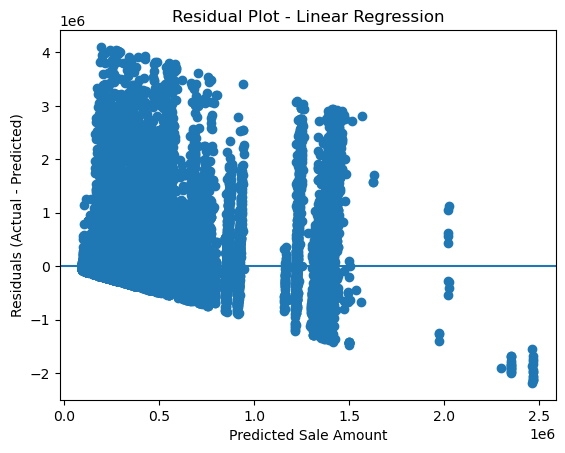

In [17]:
residuals = y_test - y_lin_pred

plt.scatter(y_lin_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Sale Amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.show()

# 5. Random Forest 

In [18]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=4,                
        max_features="sqrt",
        min_samples_leaf=20,
        min_samples_split=40,
        max_depth=18
    ))
])

rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_rf_pred))
mae  = mean_absolute_error(y_test, y_rf_pred)
r2   = r2_score(y_test, y_rf_pred)

print("Random Forest Performance:")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R2:   {r2:.4f}")

Random Forest Performance:
RMSE: 313,687.94
MAE:  160,108.89
R2:   0.5447


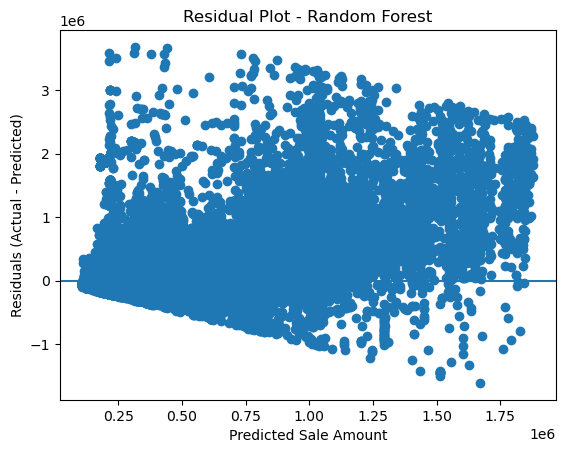

In [19]:
import matplotlib.pyplot as plt

rf_residuals = y_test - y_rf_pred
plt.scatter(y_rf_pred, rf_residuals)
plt.axhline(0)
plt.xlabel("Predicted Sale Amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")
plt.show()

In [20]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["pred"] = y_rf_pred
error_df["abs_error"] = (error_df["actual"] - error_df["pred"]).abs()

print("Worst property types by MAE:")
print(error_df.groupby("property_type")["abs_error"].mean().sort_values(ascending=False).head(10))
#Your model is much more accurate for Residential sales than for Industrial/Apartment/Commercial.

print("\nWorst towns by MAE:")
print(error_df.groupby("town")["abs_error"].mean().sort_values(ascending=False).head(10))

Worst property types by MAE:
property_type
Industrial        468053.537840
Apartments        413878.480587
Commercial        381260.390869
Public Utility    292035.844240
Vacant Land       218483.842248
Residential       146210.307639
Name: abs_error, dtype: float64

Worst towns by MAE:
town
Westport       769625.183059
Greenwich      617266.849917
Darien         616425.495444
New Canaan     606303.644772
Roxbury        482547.541646
Washington     457804.505422
Salisbury      435731.039728
Weston         422588.640799
Bridgewater    379240.165211
Warren         369331.158434
Name: abs_error, dtype: float64


# 6. Summary Comparison Table

In [21]:
results = pd.DataFrame([
    {"model": "Baseline (Median)", "rmse": 507636.15, "mae": 253681.97, "r2": -0.1925},
    {"model": "Linear Regression", "rmse": 372503.67, "mae": 185663.54, "r2": 0.3579},
    {"model": "Random Forest", "rmse": 313687.94, "mae": 160108.89, "r2": 0.5447},
])

results

,model,rmse,mae,r2
0,Baseline (Median),507636.15,253681.97,-0.1925
1,Linear Regression,372503.67,185663.54,0.3579
2,Random Forest,313687.94,160108.89,0.5447


In [22]:
# Linear error df
error_lr = X_test.copy()
error_lr["actual"] = y_test.values
error_lr["pred"] = y_lin_pred
error_lr["abs_error"] = (error_lr["actual"] - error_lr["pred"]).abs()
error_lr["model"] = "Linear"

# Random Forest error df
error_rf = X_test.copy()
error_rf["actual"] = y_test.values
error_rf["pred"] = y_rf_pred
error_rf["abs_error"] = (error_rf["actual"] - error_rf["pred"]).abs()
error_rf["model"] = "Random Forest"

both = pd.concat([error_lr[["property_type","abs_error","model"]],
                  error_rf[["property_type","abs_error","model"]]])

comparison = (
    both.groupby(["property_type","model"])["abs_error"]
        .mean()
        .unstack()
        .sort_values("Linear", ascending=False)
)

print(comparison)

model                  Linear  Random Forest
property_type                               
Industrial      677965.289321  468053.537840
Apartments      542298.773922  413878.480587
Commercial      493030.249711  381260.390869
Public Utility  324288.196237  292035.844240
Vacant Land     272448.929037  218483.842248
Residential     165764.556864  146210.307639
